In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Nind = 5
Lind = 20
Pc = 0.70
Pm = 1/15
Maxgen = 100 
Nvar = 1

rango = np.array([[0.0],
                  [0.875]])

In [3]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

In [4]:
def decodifica(genotipo, rango):
    Nvar = rango.shape[1]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))

    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j * Lvar):(j * Lvar + Lvar)])

    for i in range(Nvar):
        fenotipo[:, i] = rango[0, i] + ((rango[1, i] - rango[0, i]) / (2 ** Lvar - 1)) * fenotipo[:, i]

    return fenotipo

In [5]:
def objfun(fenotipo):
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))

    for i in range(Nind):
        x = fenotipo[i, 0]
        t = (11/2) * (x - 7/2)**2
        objv[i, 0] = 1 - t * np.cos(t) + 1 + 2

    return objv

In [6]:
def rankeo(objv, direccion):
    SP = 2
    Nind, _ = objv.shape
    aptitud = np.zeros((Nind, 1))

    if direccion == 1:
        nuevo_objv = np.sort(objv, axis=0)
    else:
        nuevo_objv = np.sort(-1 * objv, axis=0)

    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    posori = np.argsort(nuevo_objv, axis=0).flatten()
    aptitud[posori, 0] = apt

    return aptitud

In [7]:
def ruleta(genotipo, fenotipo, aptitud):
    Nind, _ = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros(Nind, dtype=int)

    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i] = aux[0]

    return genotipo[idx, :]

In [8]:
def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy().astype(float)
    par = Nind % 2

    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i, :]     = np.concatenate((nuevo_gen[i, :corte],     nuevo_gen[i+1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i+1, :corte],   nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :]     = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]

    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]

    return aux_gen.astype(int)

In [9]:
def muta(nuevo_gen, Pm):
    valores = np.random.rand(*nuevo_gen.shape)
    mascara = valores <= Pm
    return np.logical_xor(nuevo_gen, mascara).astype(int)

In [10]:
np.random.seed(42)

# Población inicial
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv     = objfun(fenotipo)

# Arreglos para guardar historial
Mejor           = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

# ── Ciclo evolutivo ──
generaciones = 1

while generaciones < Maxgen:
    aptitud   = rankeo(objv, 1)
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)

    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)

    # Guardar el mejor de esta generación
    idx = np.argmax(nuevo_objv)
    Mejor[generaciones]              = nuevo_objv[idx]
    Mejor_cromosoma[generaciones, :] = nuevo_gen[idx, :]

    # Reemplazar población
    genotipo = nuevo_gen
    objv     = nuevo_objv
    fenotipo = nuevo_feno

    generaciones += 1

print("✅ Ciclo evolutivo terminado")

✅ Ciclo evolutivo terminado


In [11]:
mejor_gen   = np.nanargmax(Mejor)
mejor_valor = Mejor[mejor_gen, 0]
mejor_cromo = Mejor_cromosoma[mejor_gen, :]
mejor_feno  = decodifica(mejor_cromo.reshape(1, -1), rango)

print("=" * 40)
print(f"  Mejor valor f(x) : {mejor_valor:.4f}")
print(f"  En generación    : {mejor_gen}")
print(f"  x = {mejor_feno[0, 0]:.6f}")
print("=" * 40)

  Mejor valor f(x) : 69.3078
  En generación    : 48
  x = 0.032451


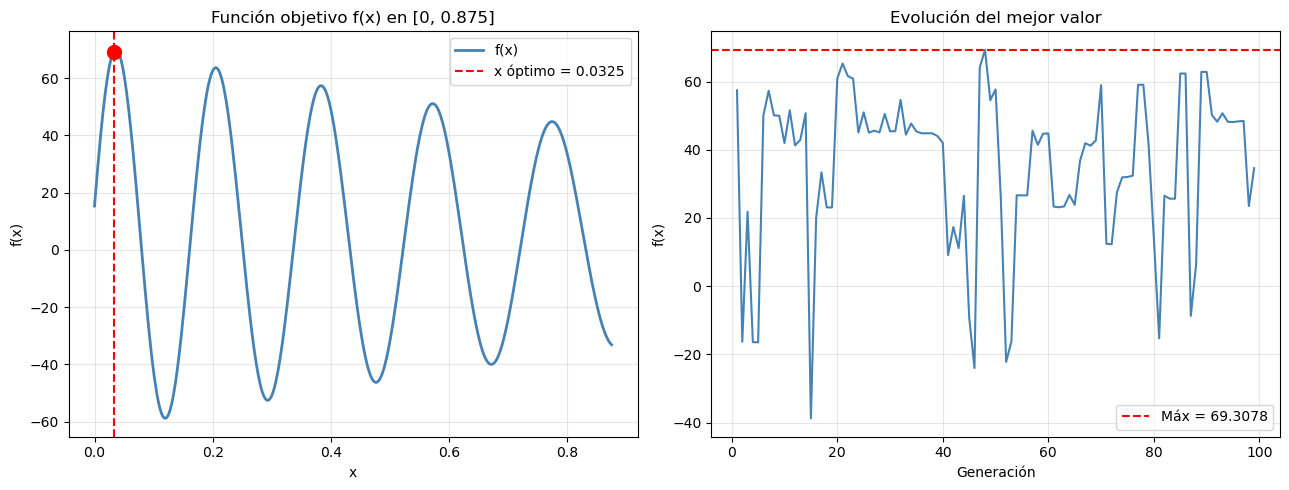

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1) Función f(x) con el óptimo encontrado
x_vals = np.linspace(0, 0.875, 500)
t_vals = (11/2) * (x_vals - 7/2)**2
y_vals = 1 - t_vals * np.cos(t_vals) + 1 + 2

axes[0].plot(x_vals, y_vals, color='steelblue', lw=2, label='f(x)')
axes[0].axvline(mejor_feno[0, 0], color='red', linestyle='--', lw=1.5,
                label=f'x óptimo = {mejor_feno[0,0]:.4f}')
axes[0].scatter(mejor_feno[0, 0], mejor_valor, color='red', s=100, zorder=5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title('Función objetivo f(x) en [0, 0.875]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2) Evolución del mejor valor por generación
gens = np.where(~np.isnan(Mejor[:, 0]))[0]
axes[1].plot(gens, Mejor[gens, 0], color='steelblue', lw=1.5)
axes[1].axhline(mejor_valor, color='red', linestyle='--',
                label=f'Máx = {mejor_valor:.4f}')
axes[1].set_xlabel('Generación')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Evolución del mejor valor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()